### MINI-PROJETO, SEMANA 07 - JONATAS H. MAGALHÃES
SETUP DE ESTRUTURA PARA ANALISE DA BASE

In [127]:
# Bibliotecas utilizadas para análise e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\ENG PC\turma-visualizacao-de-dados\modulo-01\base_do_projeto\Base Varejo.csv", sep=";", encoding="utf-8")

print("Dimensões da Base (Linhas x Colunas):", df.shape)
print()
print(df.head(3))
print()
print(df.info())
print("\nQuantidade de nulos:")
print(df.isnull().sum())
print()
display(df.describe())

Dimensões da Base (Linhas x Colunas): (830000, 14)

         DATA  CO_ID  CL_ID CL_GENERO  CL_EC  CL_FHL CL_SEG  PR_ID   PR_CAT  \
0  01/02/2019   1000    534         M      4       1      C     67  BEBIDAS   
1  01/02/2019   1000    534         M      4       1      C     70  BEBIDAS   
2  01/02/2019   1000    534         M      4       1      C    178  HIGIENE   

                PR_NOME  Unnamed: 10  Unnamed: 11  Unnamed: 12  Unnamed: 13  
0  REFRIGERANTE GUARANA          NaN          NaN          NaN          NaN  
1   REFRIGERANTE OUTROS          NaN          NaN          NaN          NaN  
2       LENCO UMEDECIDO          NaN          NaN          NaN          NaN  

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  str    
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3 

,CO_ID,CL_ID,CL_EC,CL_FHL,PR_ID,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
count,830000.00000,830000.000000,830000.000000,830000.00000,830000.000000,0.0,0.0,0.0,0.0
mean,460045.08989,499.595204,2.596911,1.14654,115.051855,NaN,NaN,NaN,NaN
std,265465.24754,287.568253,1.170599,1.41696,66.129241,NaN,NaN,NaN,NaN
min,1000.00000,1.000000,1.000000,0.00000,1.000000,NaN,NaN,NaN,NaN
25%,233117.00000,254.000000,2.000000,0.00000,58.000000,NaN,NaN,NaN,NaN
50%,456517.00000,498.000000,3.000000,0.00000,115.000000,NaN,NaN,NaN,NaN
75%,690132.00000,746.000000,4.000000,2.00000,172.000000,NaN,NaN,NaN,NaN
max,919822.00000,1000.000000,5.000000,4.00000,229.000000,NaN,NaN,NaN,NaN


### Cópia da Base para Analise
Início do processo de limpeza e análise - AED

In [129]:
# Copiando a base para a analise
df_limpo = df.copy()

# Converter DATA de str para datatime - tratando erros
df["DATA"] = pd.to_datetime(df_limpo["DATA"],
                              format="%d/%m/%Y",        # dayfirst=True → formato brasileiro (dia/mês/ano)
                              errors="coerce")      # errors="coerce" → datas inválidas viram NaT em vez de travar

print(f"Tipo de DATA após conversão: {df['DATA'].dtype}")
print(f"Datas inválidas (NaT): {df['DATA'].isna().sum()}")


Tipo de DATA após conversão: datetime64[us]
Datas inválidas (NaT): 0


In [140]:
# Tratamento de nulos - preencher com: 'Sem Categoria'
if 'PR_CAT' in df_limpo.columns:
    df_limpo['PR_CAT'] = df_limpo['PR_CAT'].fillna('Sem Categoria')
    print(f"Quantidade de Nulos Corrigidos: {df_limpo.shape[0]}")
    
# Garanti que colunas numéricas são números
cols_num = ["CO_ID", "CL_ID", "PR_ID", "CL_FHL", "CL_EC"]
for col in cols_num:
    if col in df_limpo.columns:
        df_limpo[col] = pd.to_numeric(df_limpo[col], errors="coerce")

# Exibir linhas duplicadas
linhas_duplicadas = df_limpo[df_limpo.duplicated()]
print("\nLinhas Duplicadas  :", linhas_duplicadas.shape[0])

# Eliminação de duplicatas
df_limpo1 = df_limpo.drop_duplicates()
print("\n--Eliminação de linhas duplicadas--")
print(f"Quantidade de linhas ANTES da correção: {df_limpo.shape[0]}")
print(f"Quantidade de linhas DEPOIS da correção: {df_limpo1.shape[0]}")
print(f"Total de registros inúteis eliminados: {df_limpo.shape[0] - df_limpo1.shape[0]}")

Quantidade de Nulos Corrigidos: 830000

Linhas Duplicadas  : 96553

--Eliminação de linhas duplicadas--
Quantidade de linhas ANTES da correção: 830000
Quantidade de linhas DEPOIS da correção: 733447
Total de registros inúteis eliminados: 96553


In [177]:
# Sumário estatístico geral de todas as variáveis numéricas
print("--- Sumário Estatístico Geral ---")
print(df_limpo1.describe())

--- Sumário Estatístico Geral ---
                             DATA          CO_ID          CL_ID  \
count                      733447  733447.000000  733447.000000   
mean   2020-12-06 11:20:27.215055  459941.034680     499.643996   
min           2019-01-04 00:00:00    1000.000000       1.000000   
25%           2020-01-09 00:00:00  232895.000000     254.000000   
50%           2020-12-27 00:00:00  456422.000000     498.000000   
75%           2021-10-20 00:00:00  690100.000000     746.000000   
max           2022-12-08 00:00:00  919822.000000    1000.000000   
std                           NaN  265431.394822     287.561653   

               CL_EC         CL_FHL          PR_ID  Unnamed: 10  Unnamed: 11  \
count  733447.000000  733447.000000  733447.000000          0.0          0.0   
mean        2.597385       1.146049     115.037337          NaN          NaN   
min         1.000000       0.000000       1.000000          NaN          NaN   
25%         2.000000       0.000000      5


---Estatísticas Específicas: Número de Filhos (CL_FHL)---
Média: 1.1460487260838206
Mediana: 0.0
Desvio Padrão: 1.4169173697917072
Moda: 0
Máximo: 4
Mínimo: 0
Contagem: 733447


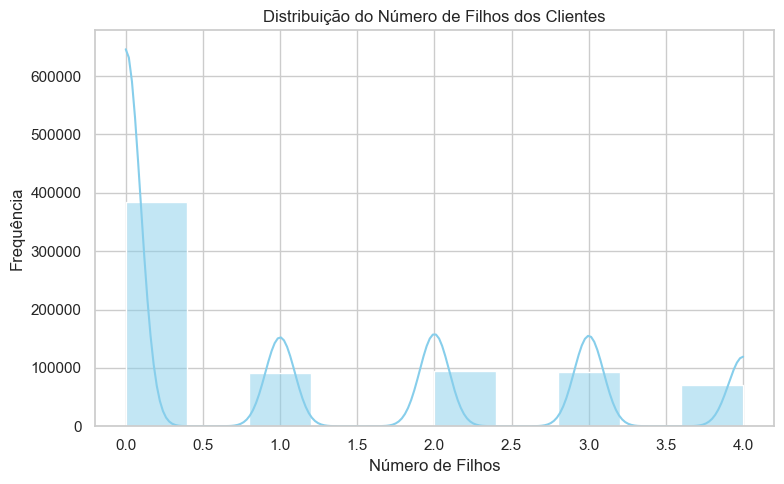

In [ ]:
# Estatísticas descritivas para a coluna filhos
if 'CL_FHL' in df_limpo1.columns:
    print("\n---Estatísticas Específicas: Número de Filhos (CL_FHL)---")
    estatisticas_filhos = {
        'Média': df_limpo1['CL_FHL'].mean(),
        'Mediana': df_limpo1['CL_FHL'].median(),
        'Desvio Padrão': df_limpo1['CL_FHL'].std(),
        'Moda': df_limpo1['CL_FHL'].mode()[0] if not df_limpo1['CL_FHL'].mode().empty else np.nan,
        'Máximo': df_limpo1['CL_FHL'].max(),
        'Mínimo': df_limpo1['CL_FHL'].min(),
        'Contagem': df_limpo1['CL_FHL'].count()
    }
    for k, v in estatisticas_filhos.items():
        print(f"{k}: {v}")

# Configuração visual padrão para os gráficos
sns.set_theme(style="whitegrid")

# 1. HISTOGRAMA (Distribuição do Número de Filhos)
if 'CL_FHL' in df_limpo1.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df_limpo1, x='CL_FHL', kde=True, bins=10, color='skyblue')
    plt.title('Distribuição do Número de Filhos dos Clientes')
    plt.xlabel('Número de Filhos')
    plt.ylabel('Frequência')
    plt.tight_layout()
    plt.show()

In [ ]:
# Estatísticas descritivas de produto por data
df_vol_pr = df_limpo1.groupby('DATA').agg(
    Volume_Itens=('DATA', 'count'),  # Contagem de itens comprados por data
    PR_CAT=('PR_CAT', 'first'),
    PR_NOME=('PR_NOME', 'first')
).reset_index()
print("\n--- Estatísticas Específicas: Volume de Itens por DATA ---")
print(df_vol_pr.head())




--- Estatísticas Específicas: Volume de Itens por DATA ---
        DATA  Volume_Itens     PR_CAT               PR_NOME
0 2019-01-04           861  ALIMENTOS        MOLHO BARBECUE
1 2019-01-13          1284  ALIMENTOS                TOMATE
2 2019-01-19           419    HIGIENE       LENCO UMEDECIDO
3 2019-01-23           789    HIGIENE               FIXADOR
4 2019-01-29          3139        PET  RACAO SECA PARA CAES


In [ ]:
# Estatísticas de produto por classe do cliente
df_vol_pr = df_limpo1.groupby('CL_SEG').agg(
    Volume_Itens=('CL_SEG', 'count'),  # Contagem de itens comprados por cliente
    CL_FHL=('CL_FHL', 'first'),
    PR_CAT=('PR_CAT', 'first'),
    PR_NOME=('PR_NOME', 'first')
).reset_index()
print("\n--- Volume de Itens por CL_SEG ---")
print(df_vol_pr.head())




--- Volume de Itens por CL_SEG ---
  CL_SEG  Volume_Itens  CL_FHL     PR_CAT               PR_NOME
0      A         59677       0    LIMPEZA                 BALDE
1      B        468505       2  ALIMENTOS      LEITE CONDENSADO
2      C        205265       1    BEBIDAS  REFRIGERANTE GUARANA



--- Matriz de Correlação ---


,CO_ID,CL_ID,CL_EC,CL_FHL,PR_ID,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
CO_ID,1.000000,0.007772,-0.011219,0.006443,-0.001452,NaN,NaN,NaN,NaN
CL_ID,0.007772,1.000000,0.022121,0.076515,-0.001005,NaN,NaN,NaN,NaN
CL_EC,-0.011219,0.022121,1.000000,-0.078287,-0.000303,NaN,NaN,NaN,NaN
CL_FHL,0.006443,0.076515,-0.078287,1.000000,0.000186,NaN,NaN,NaN,NaN
PR_ID,-0.001452,-0.001005,-0.000303,0.000186,1.000000,NaN,NaN,NaN,NaN
Unnamed: 10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unnamed: 13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


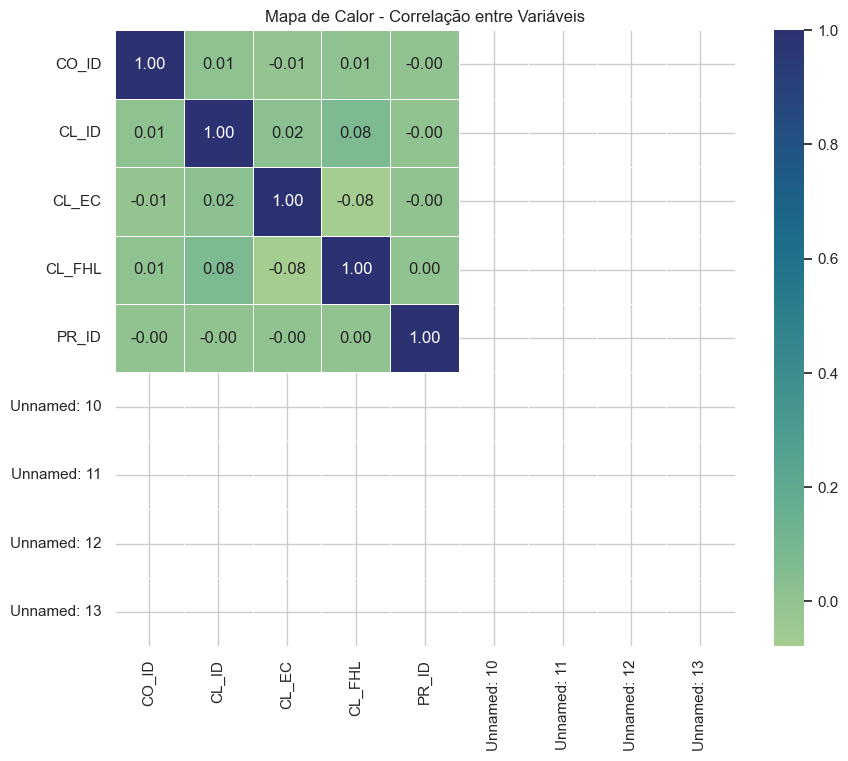

In [ ]:
print("\n--- Matriz de Correlação ---")

# Seleciona apenas as colunas numéricas para calcular a correlação
df_numerico = df_limpo1.select_dtypes(include=[np.number])
matriz_correlacao = df_numerico.corr()
display(matriz_correlacao)

# Plotando a Matriz de Correlação em um Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='crest', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor - Correlação entre Variáveis')
plt.show()

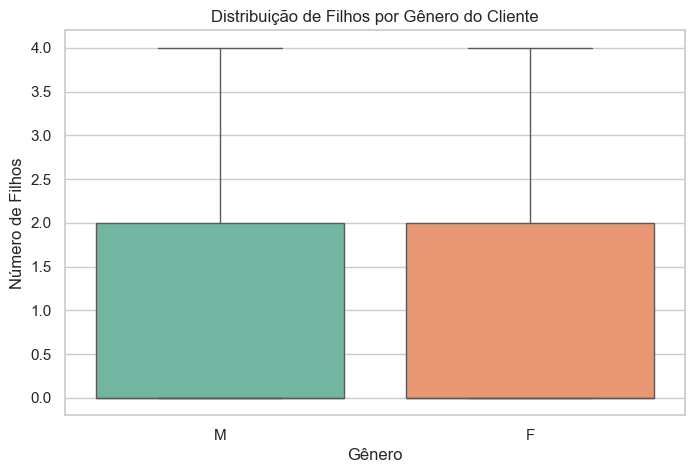

In [ ]:
# Identificação de distribuição de filhos por Gênero de cliente
if 'CL_FHL' in df_limpo1.columns and 'CL_GENERO' in df_limpo1.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_limpo1, x='CL_GENERO', y='CL_FHL', hue='CL_GENERO', palette='Set2', legend=False)
    plt.title('Distribuição de Filhos por Gênero do Cliente')
    plt.xlabel('Gênero')
    plt.ylabel('Número de Filhos')
    plt.show()

Base 100% filtrada: 0 linhas remanescentes.

O que passar do R$ 120,00 ou abaixo de R$ 20,00 será considerado outlier.


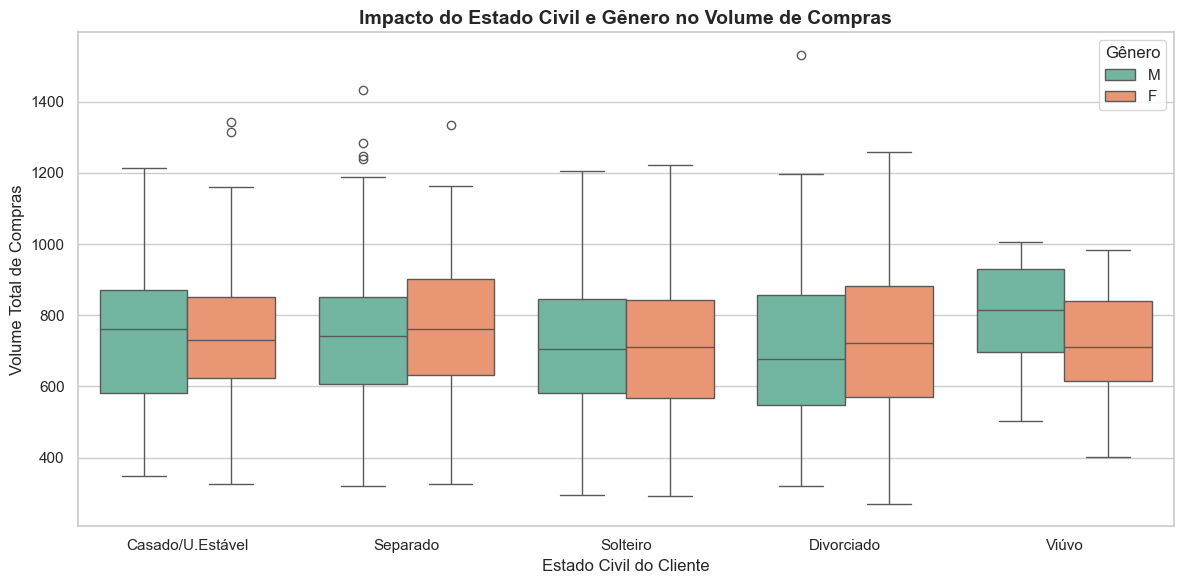

In [ ]:
df_vol_cli = df_limpo1.groupby('CL_ID').agg(
    Volume_Itens=('PR_ID', 'count'),  # Contagem de itens comprados por cliente
    CL_GENERO=('CL_GENERO', 'first'),
    CL_EC=('CL_EC', 'first')
).reset_index()

# Mapeamento do Estado Civil - Substituindo números por texto para o storytelling
dicionario_ec = {
    1: 'Casado/U.Estável',
    2: 'Divorciado',
    3: 'Separado',
    4: 'Solteiro',
    5: 'Viúvo'
}
df_vol_cli['Estado_Civil'] = df_vol_cli['CL_EC'].map(dicionario_ec)  # Criandop um dicionario

# Filtrar para Removendo os Outliers usando o método do IQR (Interquartile Range)
coluna_limpa = ["CL_EC"]  # Colunas numéricas para limpeza de outliers

for coluna in coluna_limpa:
    Q1 = df_limpo1[coluna].quantile(0.25)
    Q3 = df_limpo1[coluna].quantile(0.75)
    IQR = Q3 - Q1
    
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    # Filtra a base progressivamente
    df_limpo01 = df_limpo01[
        (df_limpo01[coluna] >= lim_inf) & (df_limpo01[coluna] <= lim_sup)
    ]

print(f"Base 100% filtrada: {df_limpo01.shape[0]} linhas remanescentes.")

df_limpo01 = df_vol_cli[
    (df_vol_cli['Volume_Itens'] >= limite_inferior) & 
    (df_vol_cli['Volume_Itens'] <= limite_superior)
]
print("\nO que passar do R$ 120,00 ou abaixo de R$ 20,00 será considerado outlier.")

# 4. Criação do Boxplot Cruzado (Estado Civil x Volume de Itens x Gênero)
plt.figure(figsize=(12, 6)) # Usamos o Estado Civil no eixo X, o Volume no eixo Y e separamos as cores pelo Gênero (hue)
sns.boxplot(
    data=df_vol_cli, 
    x='Estado_Civil', 
    y='Volume_Itens', 
    hue='CL_GENERO', 
    palette='Set2'
)
# Customização do gráfico para a apresentação
plt.title('Impacto do Estado Civil e Gênero no Volume de Compras', fontsize=14, fontweight='bold')
plt.xlabel('Estado Civil do Cliente', fontsize=12)
plt.ylabel('Volume Total de Compras', fontsize=12)
plt.legend(title='Gênero')
plt.tight_layout()
plt.show()

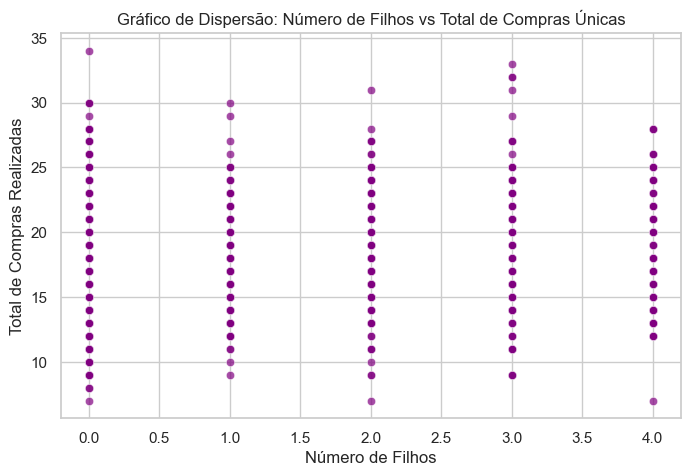

In [ ]:
# GRÁFICO DE DISPERSÃO (Scatter Plot)
# Nota: Como a base varejo possui ID de Clientes e ID de Compras, cria-se um cruzamento 
if 'CL_ID' in df_limpo1.columns and 'CO_ID' in df_limpo1.columns:

    # Criando uma visão agrupada fictícia para ilustrar o comportamento de Compras por Cliente
    df_frequencia = df_limpo1.groupby('CL_ID').agg({'CO_ID': 'nunique', 'CL_FHL': 'first'}).reset_index()
    df_frequencia.columns = ['CL_ID', 'Total_Compras', 'Num_Filhos']
    
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_frequencia, x='Num_Filhos', y='Total_Compras', alpha=0.7, color='purple')
    plt.title('Gráfico de Dispersão: Número de Filhos vs Total de Compras Únicas')
    plt.xlabel('Número de Filhos')
    plt.ylabel('Total de Compras Realizadas')
    plt.show()

In [223]:
# 2. Agrupamento (Feature Engineering): Criando métricas reais por cliente
df_analise = df_limpo1.groupby('CL_ID').agg(
    Num_Filhos=('CL_FHL', 'first'),
    Total_Compras=('CO_ID', 'nunique'),     # Conta quantas notas fiscais diferentes ele tem
    Total_Itens=('PR_NOME', 'count')       # Conta o total de linhas/produtos comprados
).reset_index()
print(df_analise['Num_Filhos'],
      df_analise['Total_Compras'],
      df_analise['Total_Itens'].fillna(0).index)
print()
# Tratar possíveis nulos no número de filhos substituindo por 0
df_analise['Num_Filhos'] = df_analise['Num_Filhos'].fillna(0)
print(df_analise['Num_Filhos'] == df_analise['Num_Filhos'].fillna(0).index)

0      0
1      0
2      0
3      0
4      3
      ..
995    4
996    2
997    0
998    2
999    1
Name: Num_Filhos, Length: 1000, dtype: int64 0      14
1      16
2      25
3      26
4      12
       ..
995    15
996    15
997    16
998    20
999    16
Name: Total_Compras, Length: 1000, dtype: int64 RangeIndex(start=0, stop=1000, step=1)

0       True
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool


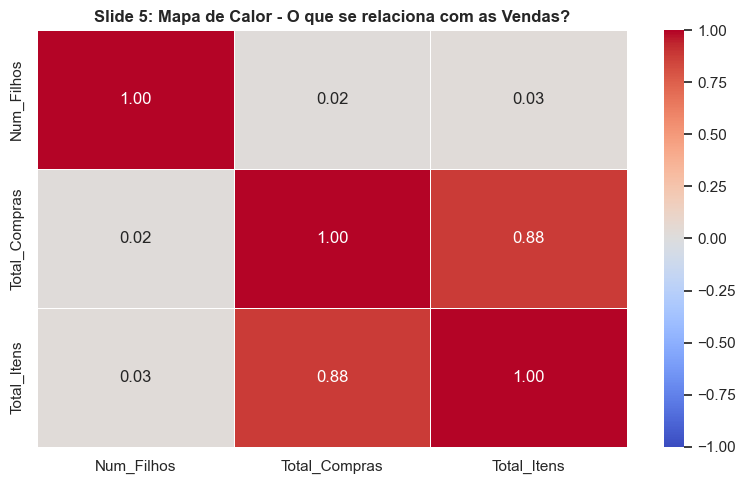

In [108]:
# GRÁFICO 1: MAPA DE CALOR (HEATMAP)
plt.figure(figsize=(8, 5))

# Calculamos a matriz de correlação apenas das colunas que importam
matriz_corr = df_analise[['Num_Filhos', 'Total_Compras', 'Total_Itens']].corr()

# Criamos o mapa de calor usando o colormap 'coolwarm' (correto!)
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Slide 5: Mapa de Calor - O que se relaciona com as Vendas?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

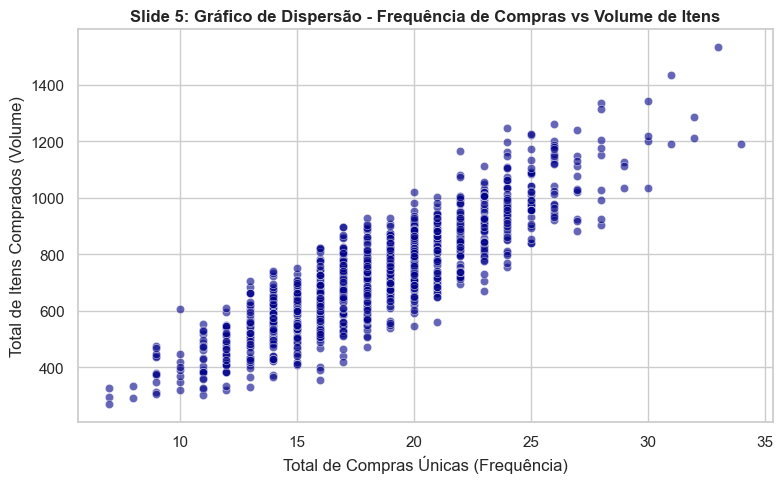

In [109]:
# GRÁFICO 2: GRÁFICO DE DISPERSÃO (SCATTER PLOT)
plt.figure(figsize=(8, 5))

# Cruzamos o Total de Compras com o Total de Itens para ver o comportamento do cliente
sns.scatterplot(
    data=df_analise, 
    x='Total_Compras', 
    y='Total_Itens', 
    alpha=0.6, 
    color='darkblue'
)

plt.title('Slide 5: Gráfico de Dispersão - Frequência de Compras vs Volume de Itens', fontsize=12, fontweight='bold')
plt.xlabel('Total de Compras Únicas (Frequência)')
plt.ylabel('Total de Itens Comprados (Volume)')
plt.tight_layout()
plt.show()